# Compute pixel weights for visual encoder pretraining

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_type_segs():
    segs = np.empty((7, 64*256, 48, 96), dtype=np.float32)

    for k in range(7):
        segs[k] = np.load(f'../data/rec_{k:02d}_img.npz')['type_seg']

    return segs.astype(np.int32)

segs = get_type_segs()
segs.shape

(7, 16384, 48, 96)

## Class representation

###  Classes per image

In [3]:
n_classes_per_img = np.zeros(segs.shape[:2], dtype=np.int32)

for i in range(segs.shape[0]):
    for j in range(segs.shape[1]):
        n_classes_per_img[i, j] = len(np.unique(segs[i, j]))

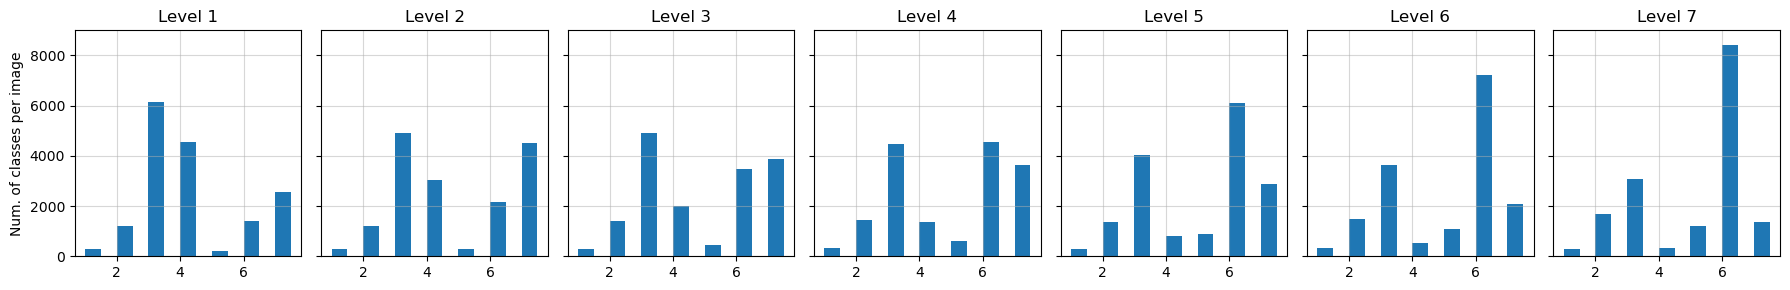

In [4]:
fig, axes = plt.subplots(1, len(segs), figsize=(18, 3))

for i in range(len(segs)):
    axes[i].hist(n_classes_per_img[i], bins=np.arange(1., 8., 0.5))
    axes[i].set_title(f'Level {i+1}')
    axes[i].grid(alpha=0.5)
    axes[i].set_ylim([0, 9000])
    
    if i > 0:
        axes[i].set_yticklabels([])

axes[0].set_ylabel('Num. of classes per image')
fig.tight_layout();

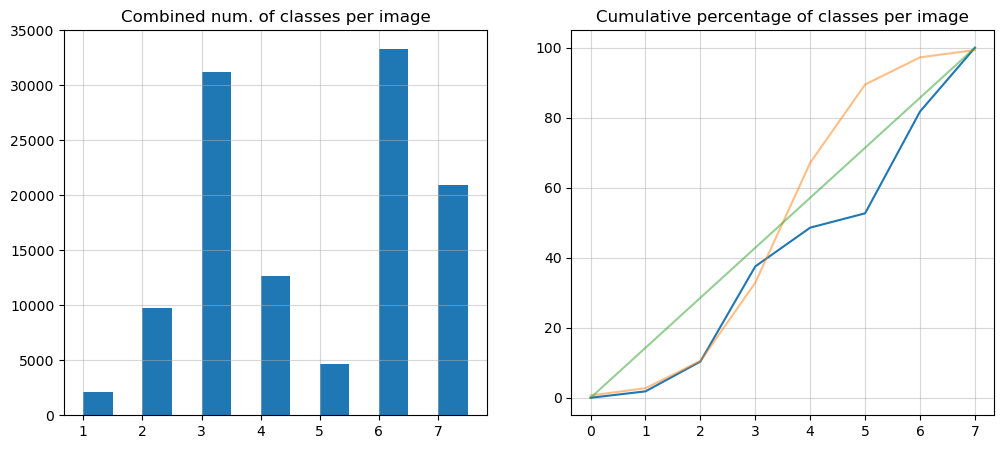

In [5]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(n_classes_per_img.flatten(), bins=np.arange(1., 8., 0.5))
ax1.set_title('Combined num. of classes per image')
ax1.grid(alpha=0.5)

ax2.plot([(n_classes_per_img < i).sum() / n_classes_per_img.size * 100. for i in range(1, 9)])
ax2.plot([100/(1+np.exp(-x)) for x in np.linspace(-5, 5, 8)], alpha=0.5)
ax2.plot(np.linspace(0., 100., 8), alpha=0.5)
ax2.grid(alpha=0.5)
ax2.set_title('Cumulative percentage of classes per image')

fig.tight_layout();

In [6]:
for i in range(1, 9):
    print(f'Perc. (n < {i}): {(n_classes_per_img < i).sum() / n_classes_per_img.size * 100.:.2f} %')

Perc. (n < 1): 0.00 %
Perc. (n < 2): 1.83 %
Perc. (n < 3): 10.35 %
Perc. (n < 4): 37.53 %
Perc. (n < 5): 48.60 %
Perc. (n < 6): 52.70 %
Perc. (n < 7): 81.77 %
Perc. (n < 8): 100.00 %


In [7]:
f'Avg.: {n_classes_per_img.sum() / n_classes_per_img.size:.3f}'

'Avg.: 4.672'

### Class distribution

In [8]:
labels = (
    'SKY',
    'GROUND',
    'WALL',
    'OBJ',
    'BOT',
    'BODY',
    'CARGO')

In [9]:
n_samples_per_class = np.zeros((len(segs), len(labels)), dtype=np.int32)

for i in range(segs.shape[0]):
    for j in range(n_samples_per_class.shape[1]):
        n_samples_per_class[i, j] = (segs[i] == j).sum()

n_combined_samples_per_class = n_samples_per_class.sum(axis=0)

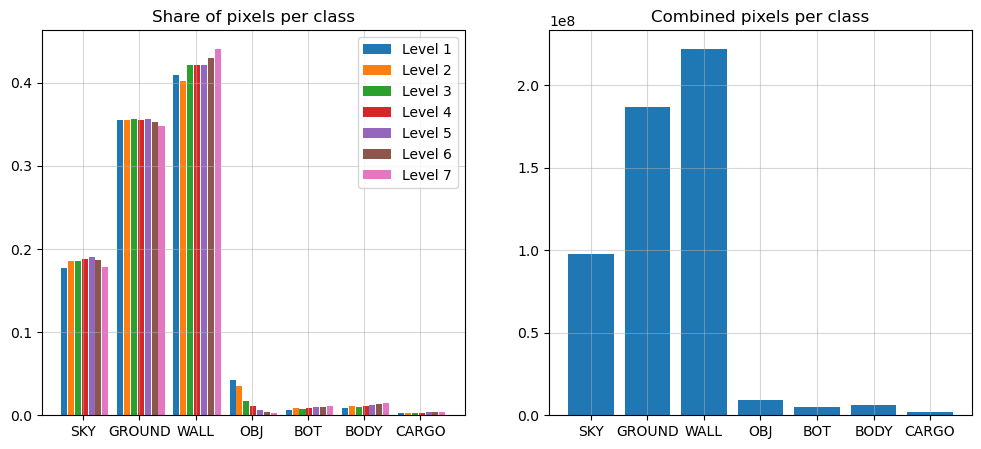

In [10]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i in range(len(segs)):
    ax1.bar(
        np.linspace(1. + i/7, 8 + i/7, 7),
        n_samples_per_class[i] / n_samples_per_class[i].sum(),
        width=1/8,
        label=f'Level {i+1}')

ax1.grid(alpha=0.5)
ax1.set_xticks(np.linspace(1.4, 8.4, 7), labels)
ax1.set_title('Share of pixels per class')
ax1.legend()

ax2.bar(np.arange(1, 8), n_combined_samples_per_class)
ax2.grid(alpha=0.5)
ax2.set_xticks(np.arange(1, 8), labels)
ax2.set_title('Combined pixels per class');

In [11]:
for i, label in enumerate(labels):
    print(f'Perc. ({label}): {n_combined_samples_per_class[i] / segs.size * 100.:.2f} %')

Perc. (SKY): 18.46 %
Perc. (GROUND): 35.39 %
Perc. (WALL): 42.04 %
Perc. (OBJ): 1.70 %
Perc. (BOT): 0.90 %
Perc. (BODY): 1.16 %
Perc. (CARGO): 0.34 %


## Weights

In [12]:
perc_map = {
    'SKY': 7.5,
    'GROUND': 7.5,
    'WALL': 40.,
    'OBJ': 22.5,
    'BOT': 5.,
    'BODY': 10.,
    'CARGO': 7.5}

# Reference weight of 1. for type OBJ
sum_of_weighted_samples = n_combined_samples_per_class[-2] * 1. / perc_map['BODY']

weight_map = {}
weight_map['SKY'] = perc_map['SKY'] * sum_of_weighted_samples / n_combined_samples_per_class[0]
weight_map['GROUND'] = perc_map['GROUND'] * sum_of_weighted_samples / n_combined_samples_per_class[1]
weight_map['WALL'] = perc_map['WALL'] * sum_of_weighted_samples / n_combined_samples_per_class[2]
weight_map['OBJ'] = perc_map['OBJ'] * sum_of_weighted_samples / n_combined_samples_per_class[3]
weight_map['BOT'] = perc_map['BOT'] * sum_of_weighted_samples / n_combined_samples_per_class[4]
weight_map['BODY'] = 1.
weight_map['CARGO'] = perc_map['CARGO'] * sum_of_weighted_samples / n_combined_samples_per_class[6]

weight_map

{'SKY': 0.04730497653376178,
 'GROUND': 0.024674143213733506,
 'WALL': 0.11077315515769617,
 'OBJ': 1.5419836422659774,
 'BOT': 0.6469855520398462,
 'BODY': 1.0,
 'CARGO': 2.5749618505882124}

## Train / test split

In [13]:
n_images = np.prod(segs.shape[:2])
n_train = round(n_images * 0.95)
n_test = n_images - n_train

n_train, n_test, n_images

(108954, 5734, 114688)

In [14]:
seg = segs.reshape((n_images, *segs.shape[2:]))

rng = np.random.default_rng(42)
random_idcs = rng.permutation(n_images)
train_idcs = random_idcs[:n_train]
test_idcs = random_idcs[n_train:]

seg_train = seg[train_idcs]
seg_test = seg[test_idcs]

In [15]:
w_samples_per_class_train = np.zeros(len(labels))
w_samples_per_class_test = np.zeros(len(labels))

for j, label in enumerate(labels):
    w_samples_per_class_train[j] = (seg_train == j).sum() * weight_map[label]
    w_samples_per_class_test[j] = (seg_test == j).sum() * weight_map[label]

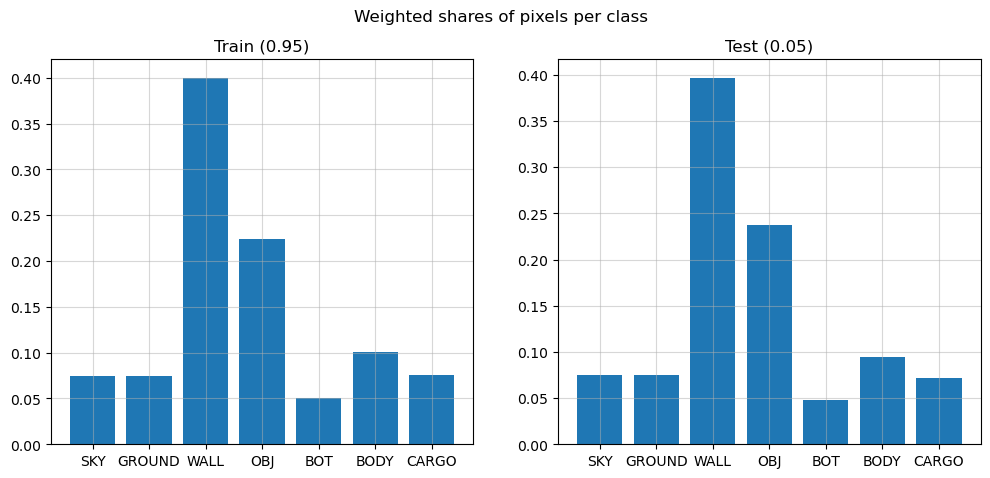

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax1.bar(np.arange(1, 8), w_samples_per_class_train / w_samples_per_class_train.sum())
ax1.grid(alpha=0.5)
ax1.set_xticks(np.arange(1, 8), labels)
ax1.set_title('Train (0.95)')

ax2.bar(np.arange(1, 8), w_samples_per_class_test / w_samples_per_class_test.sum())
ax2.grid(alpha=0.5)
ax2.set_xticks(np.arange(1, 8), labels)
ax2.set_title('Test (0.05)')

fig.suptitle('Weighted shares of pixels per class');

## Save

In [1]:
import numpy as np

In [2]:
weight_map = {
    'SKY': 0.04730497653376178,
    'GROUND': 0.024674143213733506,
    'WALL': 0.11077315515769617,
    'OBJ': 1.5419836422659774,
    'BOT': 0.6469855520398462,
    'BODY': 1.0,
    'CARGO': 2.5749618505882124}

weight_tup = (
    weight_map['SKY'],
    weight_map['GROUND'],
    weight_map['WALL'],
    weight_map['OBJ'],
    weight_map['BOT'],
    weight_map['BODY'],
    weight_map['CARGO'])

n_images = 7*64*256
n_train = round(n_images * 0.95)
n_test = n_images - n_train

rng = np.random.default_rng(42)
random_idcs = rng.permutation(n_images)
train_idcs = random_idcs[:n_train]
test_idcs = random_idcs[n_train:]

In [3]:
def save_datasets():

    # HSV (3) + depth + type seg. + clr. seg. + px. weights (4)
    full_set = np.zeros((n_images, 3+4, 48, 96), dtype=np.float32)

    slice_ptr = 0

    for k in range(7):
        print(f'Loading file {k+1} of 7...')

        img_set = np.load(f'../data/rec_{k:02d}_img.npz')
        type_seg = img_set['type_seg']

        new_slice_ptr = slice_ptr + len(type_seg)
        px_weights = np.zeros(type_seg.shape, dtype=np.float32)

        for j in range(7):
            px_weights[type_seg == j] = weight_tup[j]

        full_set[slice_ptr:new_slice_ptr, :3] = img_set['hsv']
        full_set[slice_ptr:new_slice_ptr, 3] = img_set['dep']
        full_set[slice_ptr:new_slice_ptr, 4] = type_seg
        full_set[slice_ptr:new_slice_ptr, 5] = img_set['clr_seg']
        full_set[slice_ptr:new_slice_ptr, 6] = px_weights

        slice_ptr = new_slice_ptr

    assert slice_ptr == n_images

    print('Saving...')

    np.savez_compressed('../data/rec_00-06_set.npz', train=full_set[train_idcs], test=full_set[test_idcs])

    print('Done.')

In [4]:
save_datasets()

Loading file 1 of 7...
Loading file 2 of 7...
Loading file 3 of 7...
Loading file 4 of 7...
Loading file 5 of 7...
Loading file 6 of 7...
Loading file 7 of 7...
Saving...
Done.
